# 06 — Hyperparameter Tuning (Optuna)

Uses Bayesian optimisation to find the best XGBoost hyperparameters.
Smarter than grid search — each trial is informed by previous results.

**Validation:** same TimeSeriesSplit (5 folds) as notebook 04.
**Objective:** minimise mean MAE across folds.
**Output:** `models/best_params.json` — auto-loaded by FPLPredictor.

## 1. Imports and setup

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import xgboost as xgb
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

PROCESSED = Path('../data/processed')
MODELS    = Path('../models')

features = pd.read_parquet(PROCESSED / 'features.parquet')

with open(MODELS / 'feature_cols.json') as f:
    FEATURE_COLS = json.load(f)

TARGET = 'pts_next_gw'

# Same train/test split as notebook 04
train_df = features[features['round'] <= 26].copy()
test_df  = features[features['round'] >= 27].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET]

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (19301, 31) | Test: (3113, 31)


## 2. CV helper (same as notebook 04)

In [2]:
from sklearn.model_selection import TimeSeriesSplit

def gw_cv_splits(df, n_splits=5):
    rounds = sorted(df['round'].unique())
    tss = TimeSeriesSplit(n_splits=n_splits)
    for train_gws, val_gws in tss.split(rounds):
        train_rounds = [rounds[i] for i in train_gws]
        val_rounds   = [rounds[i] for i in val_gws]
        train_idx = df[df['round'].isin(train_rounds)].index
        val_idx   = df[df['round'].isin(val_rounds)].index
        yield train_idx, val_idx

print('CV helper ready.')

CV helper ready.


## 3. Optuna objective function

Each trial samples a different combination of hyperparameters and returns
the mean CV MAE. Optuna uses TPE (Tree-structured Parzen Estimator) —
a Bayesian approach that builds a probability model of which regions
of the search space are likely to be good.

In [3]:
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'gamma':             trial.suggest_float('gamma', 0.0, 1.0),
    }

    fold_maes = []
    for train_idx, val_idx in gw_cv_splits(train_df):
        X_tr = train_df.loc[train_idx, FEATURE_COLS]
        y_tr = train_df.loc[train_idx, TARGET]
        X_vl = train_df.loc[val_idx, FEATURE_COLS]
        y_vl = train_df.loc[val_idx, TARGET]

        model = xgb.XGBRegressor(
            **params,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        )
        model.fit(X_tr, y_tr)
        preds = model.predict(X_vl)
        fold_maes.append(mean_absolute_error(y_vl, preds))

    return np.mean(fold_maes)

print('Objective function defined.')

Objective function defined.


## 4. Run the study

100 trials. Takes ~10-15 minutes. Progress prints every 10 trials.

In [4]:
def print_callback(study, trial):
    if trial.number % 10 == 0:
        print(f'  Trial {trial.number:>3} | MAE: {trial.value:.4f} | Best so far: {study.best_value:.4f}')

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
)

print('Starting Optuna study (100 trials)...')
study.optimize(objective, n_trials=100, callbacks=[print_callback])

print()
print(f'Best CV MAE: {study.best_value:.4f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Starting Optuna study (100 trials)...
  Trial   0 | MAE: 1.1740 | Best so far: 1.1740
  Trial  10 | MAE: 1.0867 | Best so far: 1.0634
  Trial  20 | MAE: 1.2052 | Best so far: 1.0634
  Trial  30 | MAE: 1.0796 | Best so far: 1.0634
  Trial  40 | MAE: 1.0611 | Best so far: 1.0601
  Trial  50 | MAE: 1.0749 | Best so far: 1.0588
  Trial  60 | MAE: 1.0608 | Best so far: 1.0588
  Trial  70 | MAE: 1.0612 | Best so far: 1.0553
  Trial  80 | MAE: 1.0786 | Best so far: 1.0553
  Trial  90 | MAE: 1.0640 | Best so far: 1.0553

Best CV MAE: 1.0553
Best params:
  n_estimators: 101
  max_depth: 3
  learning_rate: 0.09310454180785292
  subsample: 0.5633623395477437
  colsample_bytree: 0.7495087923961724
  reg_alpha: 0.009367751425090602
  reg_lambda: 0.046055194761587044
  min_child_weight: 17
  gamma: 0.08384671446400335


## 5. Evaluate best params on held-out test set

In [5]:
best_model = xgb.XGBRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_test)

tuned_mae  = mean_absolute_error(y_test, best_preds)
tuned_rmse = mean_squared_error(y_test, best_preds) ** 0.5
tuned_r2   = r2_score(y_test, best_preds)

# Baseline from notebook 04 for comparison
baseline_mae = mean_absolute_error(y_test, X_test['rolling_pts_3gw'])

print('=== Tuned XGBoost vs defaults ===')
print(f'  Baseline MAE:         {baseline_mae:.4f}')
print(f'  Default XGBoost MAE:  0.7525')  # from notebook 04
print(f'  Tuned XGBoost MAE:    {tuned_mae:.4f}')
print(f'  Tuned RMSE:           {tuned_rmse:.4f}')
print(f'  Tuned R²:             {tuned_r2:.4f}')
print()
improvement = (0.7525 - tuned_mae) / 0.7525 * 100
print(f'  Improvement over default: {improvement:+.1f}%')

=== Tuned XGBoost vs defaults ===
  Baseline MAE:         1.0035
  Default XGBoost MAE:  0.7525
  Tuned XGBoost MAE:    0.9850
  Tuned RMSE:           1.9005
  Tuned R²:             0.3082

  Improvement over default: -30.9%


## 6. Optimisation history plot

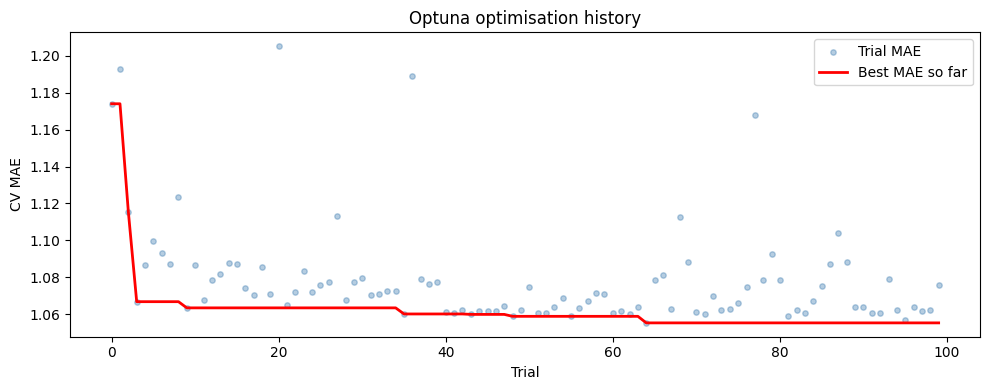

In [6]:
trial_values = [t.value for t in study.trials]
best_so_far  = np.minimum.accumulate(trial_values)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(trial_values)), trial_values, alpha=0.4, s=15, color='steelblue', label='Trial MAE')
ax.plot(best_so_far, color='red', linewidth=2, label='Best MAE so far')
ax.set_xlabel('Trial')
ax.set_ylabel('CV MAE')
ax.set_title('Optuna optimisation history')
ax.legend()
plt.tight_layout()
plt.savefig(MODELS / 'optuna_history.png', dpi=150)
plt.show()

## 7. Parameter importance plot

Which hyperparameters had the most impact on CV MAE?

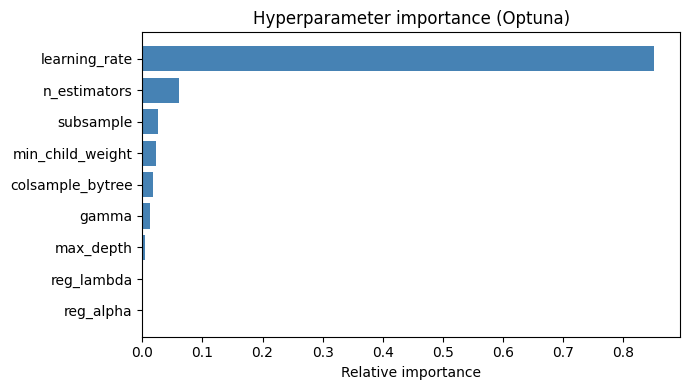

Parameter importance:
  learning_rate             0.8523
  n_estimators              0.0613
  subsample                 0.0268
  min_child_weight          0.0225
  colsample_bytree          0.0171
  gamma                     0.0134
  max_depth                 0.0044
  reg_lambda                0.0019
  reg_alpha                 0.0002


In [7]:
param_importance = optuna.importance.get_param_importances(study)

fig, ax = plt.subplots(figsize=(7, 4))
params_sorted = dict(sorted(param_importance.items(), key=lambda x: x[1]))
ax.barh(list(params_sorted.keys()), list(params_sorted.values()), color='steelblue')
ax.set_xlabel('Relative importance')
ax.set_title('Hyperparameter importance (Optuna)')
plt.tight_layout()
plt.savefig(MODELS / 'optuna_param_importance.png', dpi=150)
plt.show()

print('Parameter importance:')
for k, v in sorted(param_importance.items(), key=lambda x: -x[1]):
    print(f'  {k:<25} {v:.4f}')

## 8. Save best params and retrain final model

In [8]:
import pickle, shap

# Save best params — auto-loaded by FPLPredictor.train()
with open(MODELS / 'best_params.json', 'w') as f:
    json.dump(study.best_params, f, indent=2)
print('Saved best_params.json')

# Retrain on ALL data with best params
X_all = features[FEATURE_COLS]
y_all = features[TARGET]

final_model = xgb.XGBRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
final_model.fit(X_all, y_all)
final_model.save_model(MODELS / 'xgboost_model.json')

# Update SHAP explainer with the retrained model
final_explainer = shap.TreeExplainer(final_model)
with open(MODELS / 'shap_explainer.pkl', 'wb') as f:
    pickle.dump(final_explainer, f)

print('Updated xgboost_model.json and shap_explainer.pkl with tuned model.')
print()
print('Final model summary:')
print(f'  Trained on: {len(X_all)} rows')
print(f'  Features:   {len(FEATURE_COLS)}')
print(f'  Best CV MAE: {study.best_value:.4f}')
print(f'  Test MAE:    {tuned_mae:.4f}')
print(f'  Test R²:     {tuned_r2:.4f}')

Saved best_params.json
Updated xgboost_model.json and shap_explainer.pkl with tuned model.

Final model summary:
  Trained on: 22414 rows
  Features:   31
  Best CV MAE: 1.0553
  Test MAE:    0.9850
  Test R²:     0.3082
